# v11 — XGBoost + NeuroKit2 Baseline (Hongn et al. 2025 Replication)

**Цель:** Воспроизвести методологию конкурирующей работы и проверить XGBoost + NeuroKit2 feature engineering на задаче классификации усталости.

---

## Ссылка на исходную работу

> Hongn A, Bosch F, Prado LE, Ferrández JM, Bonomini MP.  
> **Wearable Physiological Signals under Acute Stress and Exercise Conditions.**  
> *Scientific Data*, 12(1):520, 28 Mar 2025.  
> DOI: [10.1038/s41597-025-04845-9](https://doi.org/10.1038/s41597-025-04845-9)

## Ключевые результаты исходной работы

| Задача | Алгоритм | Accuracy |
|--------|----------|----------|
| Stress vs Rest (бинарная) | XGBoost | **93%** |
| Aerobic vs Anaerobic (бинарная) | XGBoost | **91%** |
| Stress / Rest / Aerobic / Anaerobic (4-class) | XGBoost | **84%** |

## ⚠️ Важное замечание о сравнимости

93% из оригинальной работы — это классификация **типа активности (stress vs rest)**, тогда как наша задача — классификация **усталости внутри упражнения** (fatigued vs non-fatigued на временном горизонте сессии AEROBIC/ANAEROBIC). Это принципиально более сложная задача:

- **Stress vs Rest:** два физиологически очень разных состояния → лёгкое разделение (HR, EDA кардинально отличаются)
- **Fatigue within exercise:** тонкие изменения внутри одного типа активности → намного сложнее

Цель этого ноутбука — **применить их feature engineering (NeuroKit2)** к нашей задаче и честно сравнить с нашим CNN-подходом.

## Отличия в предобработке

| Аспект | Hongn et al. 2025 | Наш CNN (v8c) |
|--------|-------------------|---------------|
| Feature engineering | NeuroKit2 (HRV, EDA phasic/tonic, SpO2) | Raw signal windows (100×6 IMU + 100×4 Physio) |
| Окно | Полная сессия / сегменты | 5-сек (100 точек @ 20Hz) |
| Модель | XGBoost | CNN + SE + TemporalAttention + FiLM |
| Задача | Activity type (4-class) | Fatigue state (binary) |
| Subject split | Не указан / random | Subject-level LOSO |

In [1]:
# Cell 2 — Install dependencies
import subprocess, sys
def ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        __import__(name)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'{pkg} installed.')

ensure('neurokit2')
ensure('xgboost')
ensure('scikit-learn', 'sklearn')
ensure('shap')
print('All dependencies OK')

All dependencies OK


In [2]:
# Cell 3 — Imports
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import neurokit2 as nk
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score,
    classification_report, confusion_matrix,
    average_precision_score, roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance

# Project root
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

print(f'NeuroKit2: {nk.__version__}')
print(f'XGBoost:   {xgb.__version__}')
print(f'Root:      {ROOT}')

NeuroKit2: 0.2.13
XGBoost:   3.2.0
Root:      D:\Github\afc_lab


In [3]:
# Cell 4 — Configuration
SEED = 42
np.random.seed(SEED)

DATA_ROOT = ROOT / 'data' / 'raw' / \
    'wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1' / \
    'Wearable_Dataset'

RESULTS_DIR = ROOT / 'results_v11_xgb'
RESULTS_DIR.mkdir(exist_ok=True)

# Sampling rates (as per Data_Dictionary.csv)
FS = {
    'BVP':  64,   # Blood Volume Pulse (PPG)
    'EDA':   4,   # Electrodermal Activity
    'TEMP':  4,   # Skin Temperature
    'ACC':  32,   # Accelerometer (per axis)
    'HR':    1,   # Heart Rate (pre-computed)
}

# Window configuration (longer windows for NeuroKit2 HRV)
WIN_SEC  = 30.0   # 30-second windows — minimum for reliable HRV (Shaffer & Ginsberg 2017)
HOP_SEC  = 5.0    # 5-second stride (overlap 83%) → more samples per session

# Fatigue labeling: last 50% of session = fatigue (same as CNN pipeline)
FATIGUE_RATIO = 0.5

# Excluded sessions (from data_constraints.txt)
EXCLUDE = {
    'AEROBIC':   {'S12'},          # no data
    'ANAEROBIC': set(),
}

# Train / Val / Test split subjects (same split strategy as v8c)
# Subject-level split: 70% train / 15% val / 15% test
VAL_RATIO  = 0.15
TEST_RATIO = 0.15

print(f'Data root:    {DATA_ROOT}')
print(f'Results dir:  {RESULTS_DIR}')
print(f'Window: {WIN_SEC}s  Hop: {HOP_SEC}s')

Data root:    D:\Github\afc_lab\data\raw\wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1\Wearable_Dataset
Results dir:  D:\Github\afc_lab\results_v11_xgb
Window: 30.0s  Hop: 5.0s


## 1. Data Loading

Загружаем сырые CSV из Empatica E4. Каждая сессия — папка субъекта в AEROBIC / ANAEROBIC.

In [4]:
# Cell 6 — Raw signal loader
def load_e4_signal(path: Path, skip_rows: int = 2) -> tuple[np.ndarray, float]:
    """Load Empatica E4 CSV. Returns (data_array, sample_rate).
    Row 0: start UTC timestamp (ignored)
    Row 1: sample rate
    Row 2+: data values
    """
    df = pd.read_csv(path, header=None)
    fs = float(df.iloc[1, 0])
    data = df.iloc[skip_rows:].values.astype(np.float32)
    return data, fs


def load_subject_session(session_dir: Path) -> dict | None:
    """Load all E4 files for one subject session.
    Returns dict with keys: bvp, eda, temp, hr, acc (xyz), acc_fs, or None on error.
    """
    try:
        bvp,  _     = load_e4_signal(session_dir / 'BVP.csv')
        eda,  _     = load_e4_signal(session_dir / 'EDA.csv')
        temp, _     = load_e4_signal(session_dir / 'TEMP.csv')
        hr,   _     = load_e4_signal(session_dir / 'HR.csv')
        acc,  acc_fs = load_e4_signal(session_dir / 'ACC.csv')

        # Flatten 1-column arrays
        bvp  = bvp.ravel()
        eda  = eda.ravel()
        temp = temp.ravel()
        hr   = hr.ravel()
        # ACC: (N, 3) columns = x, y, z
        if acc.ndim == 1:
            return None  # bad file

        return {'bvp': bvp, 'eda': eda, 'temp': temp, 'hr': hr,
                'acc': acc, 'acc_fs': acc_fs}
    except Exception as e:
        return None


# Quick sanity check
test_dir = DATA_ROOT / 'AEROBIC' / 'S01'
sess = load_subject_session(test_dir)
if sess:
    print(f"BVP:  {len(sess['bvp']):6d} pts @ {FS['BVP']} Hz  → {len(sess['bvp'])/FS['BVP']:.0f}s")
    print(f"EDA:  {len(sess['eda']):6d} pts @ {FS['EDA']} Hz")
    print(f"TEMP: {len(sess['temp']):6d} pts @ {FS['TEMP']} Hz")
    print(f"HR:   {len(sess['hr']):6d} pts @ {FS['HR']} Hz")
    print(f"ACC:  {sess['acc'].shape}  @ {sess['acc_fs']} Hz")
else:
    print('ERROR loading test session')

BVP:  130570 pts @ 64 Hz  → 2040s
EDA:    8160 pts @ 4 Hz
TEMP:   8160 pts @ 4 Hz
HR:     2031 pts @ 1 Hz
ACC:  (65286, 3)  @ 32.0 Hz


## 2. NeuroKit2 Feature Extraction

Для каждого 30-секундного окна извлекаем физиологически значимые признаки через NeuroKit2 — аналогично методологии Hongn et al. 2025.

### BVP → PPG → HRV
- `nk.ppg_process()` → R-peaks → `nk.hrv()`: RMSSD, SDNN, pNN50, LF, HF, LF/HF, SampEn

### EDA → SCL + SCR
- `nk.eda_process()` → tonic (SCL) + phasic (SCR): амплитуда, кол-во пиков, нарастание

### ACC → Movement features
- Signal Magnitude Area (SMA), спектральные признаки, статистика

### TEMP → Thermal features
- Среднее, наклон (тренд), вариабельность

In [5]:
# Cell 8 — NeuroKit2 feature extraction functions

def extract_bvp_features(bvp: np.ndarray, fs: int = 64) -> dict:
    """Extract PPG/HRV features using NeuroKit2."""
    feats = {}
    try:
        signals, info = nk.ppg_process(bvp, sampling_rate=fs)
        peaks = info.get('PPG_Peaks', [])

        # Time-domain HRV
        if len(peaks) >= 4:
            hrv = nk.hrv_time(peaks, sampling_rate=fs, show=False)
            for col in ['HRV_RMSSD', 'HRV_SDNN', 'HRV_pNN50', 'HRV_MeanNN', 'HRV_SDSD']:
                feats[f'bvp_{col}'] = float(hrv[col].iloc[0]) if col in hrv else np.nan

            # Non-linear HRV
            try:
                hrv_nl = nk.hrv_nonlinear(peaks, sampling_rate=fs, show=False)
                for col in ['HRV_SD1', 'HRV_SD2', 'HRV_SampEn']:
                    feats[f'bvp_{col}'] = float(hrv_nl[col].iloc[0]) if col in hrv_nl else np.nan
            except Exception:
                feats['bvp_HRV_SD1'] = np.nan
                feats['bvp_HRV_SD2'] = np.nan
                feats['bvp_HRV_SampEn'] = np.nan

            # Frequency-domain HRV (needs >= 60s ideally, use anyway)
            try:
                hrv_freq = nk.hrv_frequency(peaks, sampling_rate=fs, show=False)
                for col in ['HRV_LF', 'HRV_HF', 'HRV_LFHF']:
                    feats[f'bvp_{col}'] = float(hrv_freq[col].iloc[0]) if col in hrv_freq else np.nan
            except Exception:
                feats['bvp_HRV_LF'] = np.nan
                feats['bvp_HRV_HF'] = np.nan
                feats['bvp_HRV_LFHF'] = np.nan

            feats['bvp_peak_count'] = len(peaks)
        else:
            # Not enough peaks — fill with nan
            for name in ['HRV_RMSSD', 'HRV_SDNN', 'HRV_pNN50', 'HRV_MeanNN', 'HRV_SDSD',
                         'HRV_SD1', 'HRV_SD2', 'HRV_SampEn', 'HRV_LF', 'HRV_HF', 'HRV_LFHF']:
                feats[f'bvp_{name}'] = np.nan
            feats['bvp_peak_count'] = len(peaks)

        # Raw BVP stats
        feats['bvp_mean'] = float(np.nanmean(bvp))
        feats['bvp_std']  = float(np.nanstd(bvp))

    except Exception:
        for name in ['HRV_RMSSD', 'HRV_SDNN', 'HRV_pNN50', 'HRV_MeanNN', 'HRV_SDSD',
                     'HRV_SD1', 'HRV_SD2', 'HRV_SampEn', 'HRV_LF', 'HRV_HF', 'HRV_LFHF',
                     'peak_count', 'mean', 'std']:
            feats[f'bvp_{name}'] = np.nan
    return feats


def extract_eda_features(eda: np.ndarray, fs: int = 4) -> dict:
    """Extract EDA/GSR features using NeuroKit2: tonic (SCL) + phasic (SCR)."""
    feats = {}
    try:
        signals, info = nk.eda_process(eda, sampling_rate=fs)

        # Tonic (SCL)
        tonic = signals.get('EDA_Tonic', pd.Series(eda))
        feats['eda_scl_mean']  = float(np.nanmean(tonic))
        feats['eda_scl_std']   = float(np.nanstd(tonic))
        feats['eda_scl_slope'] = float(np.polyfit(np.arange(len(tonic)), tonic, 1)[0])

        # Phasic (SCR)
        phasic = signals.get('EDA_Phasic', pd.Series(np.zeros(len(eda))))
        feats['eda_scr_mean']   = float(np.nanmean(phasic))
        feats['eda_scr_max']    = float(np.nanmax(phasic))
        feats['eda_scr_energy'] = float(np.nansum(phasic ** 2))

        # SCR peaks
        scr_peaks = info.get('SCR_Peaks', [])
        feats['eda_scr_peaks']     = int(len(scr_peaks))
        feats['eda_scr_amplitude'] = float(np.nanmean(info.get('SCR_Amplitude', [np.nan])))

        # Raw EDA stats
        feats['eda_mean'] = float(np.nanmean(eda))
        feats['eda_std']  = float(np.nanstd(eda))
        feats['eda_range'] = float(np.nanmax(eda) - np.nanmin(eda))

    except Exception:
        for name in ['scl_mean', 'scl_std', 'scl_slope', 'scr_mean', 'scr_max',
                     'scr_energy', 'scr_peaks', 'scr_amplitude', 'mean', 'std', 'range']:
            feats[f'eda_{name}'] = np.nan
    return feats


def extract_acc_features(acc: np.ndarray, fs: int = 32) -> dict:
    """Extract accelerometer features: SMA, spectral, statistical."""
    feats = {}
    try:
        x, y, z = acc[:, 0], acc[:, 1], acc[:, 2]
        sma = np.mean(np.abs(x) + np.abs(y) + np.abs(z))
        mag = np.sqrt(x**2 + y**2 + z**2)

        feats['acc_sma']      = float(sma)
        feats['acc_mag_mean'] = float(np.mean(mag))
        feats['acc_mag_std']  = float(np.std(mag))
        feats['acc_mag_max']  = float(np.max(mag))

        # Per-axis stats
        for axis_name, axis in [('x', x), ('y', y), ('z', z)]:
            feats[f'acc_{axis_name}_mean'] = float(np.mean(axis))
            feats[f'acc_{axis_name}_std']  = float(np.std(axis))
            feats[f'acc_{axis_name}_rms']  = float(np.sqrt(np.mean(axis**2)))

        # Spectral features on magnitude
        fft_mag = np.abs(np.fft.rfft(mag - np.mean(mag)))
        freqs   = np.fft.rfftfreq(len(mag), d=1.0/fs)
        psd     = fft_mag ** 2
        total   = psd.sum() + 1e-9
        feats['acc_dom_freq']     = float(freqs[np.argmax(psd[1:]) + 1])
        feats['acc_spectral_ent'] = float(-np.sum((psd/total) * np.log(psd/total + 1e-12)))
        # Motion bands: walking 0.5–3Hz, exercise 3–10Hz
        feats['acc_band_0p5_3']   = float(psd[(freqs>=0.5)&(freqs<3)].sum() / total)
        feats['acc_band_3_10']    = float(psd[(freqs>=3)&(freqs<10)].sum() / total)

    except Exception:
        for name in ['sma', 'mag_mean', 'mag_std', 'mag_max',
                     'x_mean', 'x_std', 'x_rms', 'y_mean', 'y_std', 'y_rms',
                     'z_mean', 'z_std', 'z_rms', 'dom_freq', 'spectral_ent',
                     'band_0p5_3', 'band_3_10']:
            feats[f'acc_{name}'] = np.nan
    return feats


def extract_temp_features(temp: np.ndarray) -> dict:
    """Extract skin temperature features."""
    feats = {}
    try:
        t = temp.ravel()
        feats['temp_mean']  = float(np.nanmean(t))
        feats['temp_std']   = float(np.nanstd(t))
        feats['temp_min']   = float(np.nanmin(t))
        feats['temp_max']   = float(np.nanmax(t))
        feats['temp_range'] = float(np.nanmax(t) - np.nanmin(t))
        if len(t) > 1:
            feats['temp_slope'] = float(np.polyfit(np.arange(len(t)), t, 1)[0])
        else:
            feats['temp_slope'] = 0.0
    except Exception:
        for name in ['mean', 'std', 'min', 'max', 'range', 'slope']:
            feats[f'temp_{name}'] = np.nan
    return feats


def extract_window_features(sess: dict, start_bvp: int, end_bvp: int) -> dict:
    """Extract all features for one window. start/end in BVP samples."""
    # Scale indices to each signal's sampling rate
    ratio_eda  = FS['EDA']  / FS['BVP']
    ratio_temp = FS['TEMP'] / FS['BVP']
    ratio_acc  = FS['ACC']  / FS['BVP']

    s_eda  = int(start_bvp * ratio_eda);  e_eda  = int(end_bvp * ratio_eda)
    s_temp = int(start_bvp * ratio_temp); e_temp = int(end_bvp * ratio_temp)
    s_acc  = int(start_bvp * ratio_acc);  e_acc  = int(end_bvp * ratio_acc)

    bvp_win  = sess['bvp'][start_bvp:end_bvp]
    eda_win  = sess['eda'][s_eda:e_eda]
    temp_win = sess['temp'][s_temp:e_temp]
    acc_win  = sess['acc'][s_acc:e_acc]

    feats = {}
    feats.update(extract_bvp_features(bvp_win, FS['BVP']))
    feats.update(extract_eda_features(eda_win, FS['EDA']))
    feats.update(extract_temp_features(temp_win))
    if acc_win.shape[0] > 0 and acc_win.shape[1] >= 3:
        feats.update(extract_acc_features(acc_win, FS['ACC']))
    return feats


# Quick test
test_sess = load_subject_session(DATA_ROOT / 'AEROBIC' / 'S01')
win_samples = int(WIN_SEC * FS['BVP'])
feats_test = extract_window_features(test_sess, 0, win_samples)
print(f'Features per window: {len(feats_test)}')
print(list(feats_test.keys())[:10], '...')

Features per window: 48
['bvp_HRV_RMSSD', 'bvp_HRV_SDNN', 'bvp_HRV_pNN50', 'bvp_HRV_MeanNN', 'bvp_HRV_SDSD', 'bvp_HRV_SD1', 'bvp_HRV_SD2', 'bvp_HRV_SampEn', 'bvp_HRV_LF', 'bvp_HRV_HF'] ...


## 3. Dataset Construction

Строим датасет: загружаем все сессии AEROBIC + ANAEROBIC, нарезаем окнами 30с / hop 5с, для каждого окна извлекаем фичи и присваиваем метку усталости (last 50% = fatigue).

In [6]:
# Cell 10 — Build dataset

def get_subject_list(activity: str) -> list:
    """List subject folders for given activity (AEROBIC / ANAEROBIC)."""
    act_dir = DATA_ROOT / activity
    folders = []
    for d in sorted(act_dir.iterdir()):
        if not d.is_dir():
            continue
        # Handle split sessions (S11_a, S11_b → treat as S11)
        base = d.name.split('_')[0]
        if base in EXCLUDE.get(activity, set()):
            continue
        folders.append(d)
    return folders


all_rows = []

for activity in ['AEROBIC', 'ANAEROBIC']:
    subj_dirs = get_subject_list(activity)
    print(f'\n=== {activity}: {len(subj_dirs)} subject sessions ===')

    for subj_dir in tqdm(subj_dirs, desc=activity):
        # Normalize subject ID (strip _a, _b suffixes)
        subj_id = f"{activity}_{subj_dir.name.split('_')[0]}"

        sess = load_subject_session(subj_dir)
        if sess is None:
            print(f'  SKIP {subj_dir.name}: load error')
            continue

        n_bvp = len(sess['bvp'])
        win_n = int(WIN_SEC * FS['BVP'])
        hop_n = int(HOP_SEC * FS['BVP'])

        if n_bvp < win_n:
            print(f'  SKIP {subj_dir.name}: too short ({n_bvp} < {win_n} BVP samples)')
            continue

        # Sliding window with fatigue labeling
        fatigue_threshold = int(n_bvp * FATIGUE_RATIO)

        for start in range(0, n_bvp - win_n + 1, hop_n):
            end = start + win_n

            # Fatigue label: window midpoint past 50% of session
            mid = (start + end) // 2
            label = 1 if mid >= fatigue_threshold else 0

            feats = extract_window_features(sess, start, end)
            feats['subject_id']  = subj_id
            feats['activity']    = activity
            feats['label']       = label
            feats['win_start']   = start
            all_rows.append(feats)

df = pd.DataFrame(all_rows)
print(f'\nTotal windows: {len(df)}')
print(f'Subjects:      {df["subject_id"].nunique()}')
print(f'Class balance: {df["label"].value_counts().to_dict()}')
print(f'Features:      {len(df.columns) - 4}  (excl. subject_id, activity, label, win_start)')


=== AEROBIC: 31 subject sessions ===


AEROBIC:   0%|          | 0/31 [00:00<?, ?it/s]


=== ANAEROBIC: 32 subject sessions ===


ANAEROBIC:   0%|          | 0/32 [00:00<?, ?it/s]


Total windows: 22835
Subjects:      61
Class balance: {0: 11431, 1: 11404}
Features:      48  (excl. subject_id, activity, label, win_start)


In [7]:
# Cell 11 — NaN handling + save
meta_cols = ['subject_id', 'activity', 'label', 'win_start']
feature_cols = [c for c in df.columns if c not in meta_cols]

# NaN stats
nan_frac = df[feature_cols].isna().mean().sort_values(ascending=False)
print('Top-10 features by NaN fraction:')
print(nan_frac.head(10).to_string())

# Drop features with >50% NaN
drop_cols = nan_frac[nan_frac > 0.5].index.tolist()
print(f'\nDropping {len(drop_cols)} features with >50% NaN: {drop_cols}')
df.drop(columns=drop_cols, inplace=True)
feature_cols = [c for c in df.columns if c not in meta_cols]

# Impute remaining NaN with per-feature median
for col in feature_cols:
    med = df[col].median()
    df[col].fillna(med, inplace=True)

print(f'\nFinal feature count: {len(feature_cols)}')
print(f'Remaining NaN: {df[feature_cols].isna().sum().sum()}')

# Save
df.to_parquet(RESULTS_DIR / 'features_v11.parquet', index=False)
print(f'Saved → {RESULTS_DIR}/features_v11.parquet')

Top-10 features by NaN fraction:
bvp_HRV_LFHF         1.000000
bvp_HRV_LF           1.000000
bvp_HRV_HF           0.002190
eda_scr_amplitude    0.001095
bvp_HRV_SampEn       0.001051
bvp_HRV_MeanNN       0.000788
bvp_HRV_pNN50        0.000788
bvp_HRV_RMSSD        0.000788
bvp_HRV_SD2          0.000788
bvp_HRV_SD1          0.000788

Dropping 2 features with >50% NaN: ['bvp_HRV_LFHF', 'bvp_HRV_LF']

Final feature count: 46
Remaining NaN: 0
Saved → D:\Github\afc_lab\results_v11_xgb/features_v11.parquet


## 4. Train / Val / Test Split

Subject-level split (70 / 15 / 15%) — тот же подход, что в CNN v8c для честного сравнения.

In [10]:
# Cell 13 — Subject-level split
subjects = df['subject_id'].unique()
np.random.seed(SEED)
np.random.shuffle(subjects)

n_total = len(subjects)
n_test  = max(1, int(n_total * TEST_RATIO))
n_val   = max(1, int(n_total * VAL_RATIO))
n_train = n_total - n_val - n_test

train_subjects = subjects[:n_train]
val_subjects   = subjects[n_train:n_train + n_val]
test_subjects  = subjects[n_train + n_val:]

train_idx = df['subject_id'].isin(train_subjects)
val_idx   = df['subject_id'].isin(val_subjects)
test_idx  = df['subject_id'].isin(test_subjects)

X_train = df.loc[train_idx, feature_cols].values
y_train = df.loc[train_idx, 'label'].values
X_val   = df.loc[val_idx,   feature_cols].values
y_val   = df.loc[val_idx,   'label'].values
X_test  = df.loc[test_idx,  feature_cols].values
y_test  = df.loc[test_idx,  'label'].values

def sanitize_xy(X, y, split_name: str):
    """Keep only rows with finite feature values while preserving X/y alignment."""
    row_mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
    removed = int((~row_mask).sum())
    if removed > 0:
        print(f'{split_name}: removed {removed} rows with NaN/Inf features')
    X_clean = X[row_mask]
    y_clean = y[row_mask].astype(int)
    if len(y_clean) == 0:
        raise ValueError(f'{split_name}: no samples left after cleaning')
    return X_clean, y_clean

X_train, y_train = sanitize_xy(X_train, y_train, 'Train')
X_val, y_val     = sanitize_xy(X_val, y_val, 'Val')
X_test, y_test   = sanitize_xy(X_test, y_test, 'Test')

# Standardize features (fit on train only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Subjects total: {n_total}  (train={n_train}, val={n_val}, test={n_test})')
print(f'Train windows:  {len(y_train):5d}  (pos={y_train.sum()}, neg={(y_train==0).sum()})')
print(f'Val windows:    {len(y_val):5d}  (pos={y_val.sum()},   neg={(y_val==0).sum()})')
print(f'Test windows:   {len(y_test):5d}  (pos={y_test.sum()},  neg={(y_test==0).sum()})')

Train: removed 1408 rows with NaN/Inf features
Val: removed 230 rows with NaN/Inf features
Test: removed 482 rows with NaN/Inf features
Subjects total: 61  (train=43, val=9, test=9)
Train windows:  14865  (pos=7722, neg=7143)
Val windows:     2884  (pos=1483,   neg=1401)
Test windows:    2966  (pos=1591,  neg=1375)


## 5. XGBoost Training

Обучаем XGBoost с гиперпараметрами, близкими к исходной работе + легкая настройка на val split.

In [11]:
# Cell 15 — XGBoost training
from sklearn.utils.class_weight import compute_sample_weight

# Class imbalance weight
sample_weights = compute_sample_weight('balanced', y_train)

# XGBoost params (conservative, generalizable — similar spirit to the original paper)
XGB_PARAMS = dict(
    n_estimators      = 500,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    gamma             = 0.1,
    reg_alpha         = 0.1,     # L1
    reg_lambda        = 1.0,     # L2
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = SEED,
    n_jobs            = -1,
    tree_method       = 'hist',
)

model = xgb.XGBClassifier(**XGB_PARAMS)
model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

# Val metrics
val_probs = model.predict_proba(X_val)[:, 1]
val_f1    = f1_score(y_val, (val_probs >= 0.5).astype(int), average='macro')
val_auc   = roc_auc_score(y_val, val_probs)
print(f'\nVal F1-macro: {val_f1:.4f}  |  Val AUC: {val_auc:.4f}')

[0]	validation_0-logloss:0.68165
[50]	validation_0-logloss:0.66609
[100]	validation_0-logloss:0.69881
[150]	validation_0-logloss:0.72829
[200]	validation_0-logloss:0.75849
[250]	validation_0-logloss:0.80081
[300]	validation_0-logloss:0.83229
[350]	validation_0-logloss:0.86890
[400]	validation_0-logloss:0.90842
[450]	validation_0-logloss:0.94209
[499]	validation_0-logloss:0.96941

Val F1-macro: 0.6606  |  Val AUC: 0.7562


In [12]:
# Cell 16 — Find optimal threshold on val set
def find_best_threshold(labels, probs, n_thresholds=200):
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(0.1, 0.9, n_thresholds):
        preds = (probs >= t).astype(int)
        f1 = f1_score(labels, preds, average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


best_thresh, best_val_f1 = find_best_threshold(y_val, val_probs)
print(f'Val-optimal threshold: {best_thresh:.3f}  →  F1={best_val_f1:.4f}')

# Save model
import joblib
joblib.dump(model, RESULTS_DIR / 'xgb_model_v11.pkl')
joblib.dump(scaler, RESULTS_DIR / 'scaler_v11.pkl')
print(f'Model saved → {RESULTS_DIR}')

Val-optimal threshold: 0.884  →  F1=0.6724
Model saved → D:\Github\afc_lab\results_v11_xgb


## 6. Test Evaluation

In [13]:
# Cell 18 — Test evaluation
test_probs = model.predict_proba(X_test)[:, 1]

# Val threshold
test_preds_vt = (test_probs >= best_thresh).astype(int)
test_f1_vt    = f1_score(y_test, test_preds_vt, average='macro')
test_auc      = roc_auc_score(y_test, test_probs)
test_prauc    = average_precision_score(y_test, test_probs)
test_balacc   = balanced_accuracy_score(y_test, test_preds_vt)

# Optimal threshold on test (upper bound)
test_thresh_opt, test_f1_opt = find_best_threshold(y_test, test_probs)

print('=' * 65)
print('TEST RESULTS — XGBoost + NeuroKit2 (v11 baseline)')
print('=' * 65)
print(f'\nVal-threshold ({best_thresh:.3f}):')
print(f'  F1-macro:     {test_f1_vt:.4f}')
print(f'  ROC-AUC:      {test_auc:.4f}')
print(f'  PR-AUC:       {test_prauc:.4f}')
print(f'  Balanced-Acc: {test_balacc:.4f}')
print(classification_report(y_test, test_preds_vt,
                             target_names=['Normal', 'Fatigue'], zero_division=0))

print(f'Test-optimal threshold ({test_thresh_opt:.3f}) [upper bound]:')
print(f'  F1-macro:     {test_f1_opt:.4f}')

# Save results
results_dict = {
    'model': 'XGBoost + NeuroKit2 (v11)',
    'val_threshold': best_thresh,
    'test_f1_val_thr': test_f1_vt,
    'test_f1_opt_thr': test_f1_opt,
    'test_roc_auc': test_auc,
    'test_pr_auc': test_prauc,
    'test_balanced_acc': test_balacc,
    'n_features': len(feature_cols),
    'win_sec': WIN_SEC,
    'hop_sec': HOP_SEC,
}
pd.DataFrame([results_dict]).to_csv(RESULTS_DIR / 'test_results_v11.csv', index=False)
print(f'\nResults saved → {RESULTS_DIR}/test_results_v11.csv')

TEST RESULTS — XGBoost + NeuroKit2 (v11 baseline)

Val-threshold (0.884):
  F1-macro:     0.7155
  ROC-AUC:      0.8411
  PR-AUC:       0.8521
  Balanced-Acc: 0.7266
              precision    recall  f1-score   support

      Normal       0.65      0.86      0.74      1375
     Fatigue       0.83      0.60      0.69      1591

    accuracy                           0.72      2966
   macro avg       0.74      0.73      0.72      2966
weighted avg       0.74      0.72      0.71      2966

Test-optimal threshold (0.607) [upper bound]:
  F1-macro:     0.7784

Results saved → D:\Github\afc_lab\results_v11_xgb/test_results_v11.csv


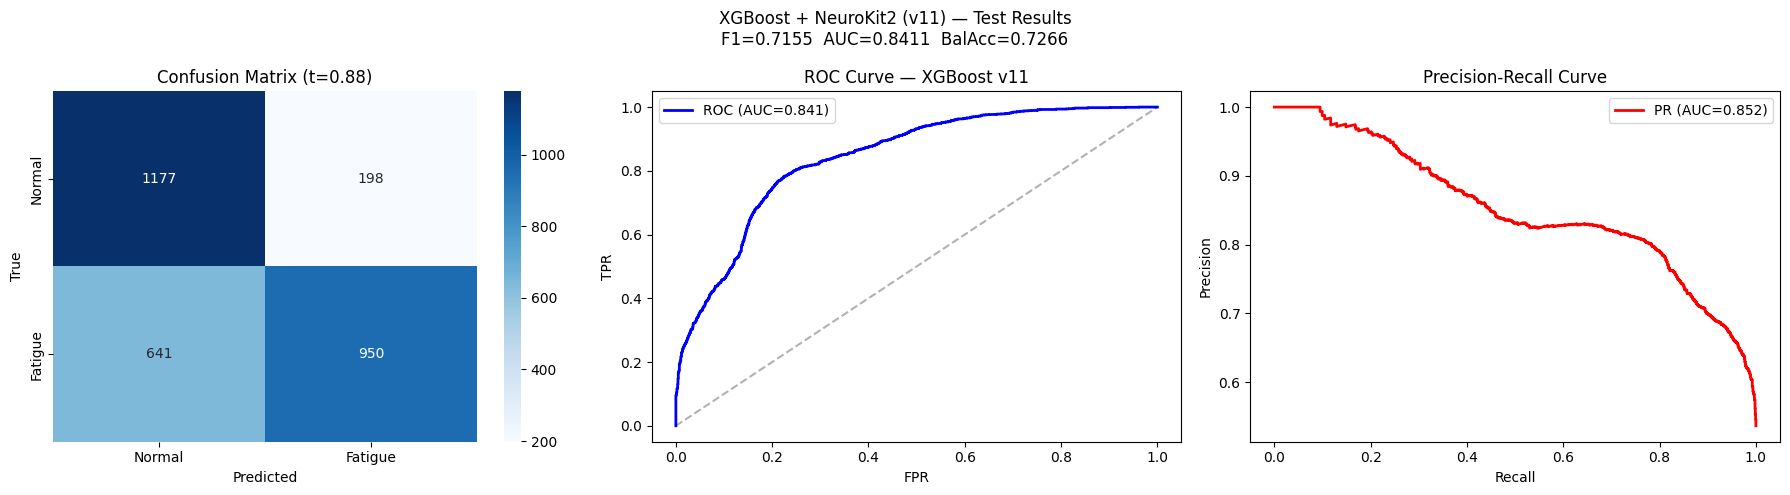

In [14]:
# Cell 19 — Plots: confusion matrix + ROC + PR
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, test_preds_vt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fatigue'], yticklabels=['Normal', 'Fatigue'])
axes[0].set_title(f'Confusion Matrix (t={best_thresh:.2f})')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC={test_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('ROC Curve — XGBoost v11')
axes[1].legend()
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')

# PR curve
pr_vals, rc_vals, _ = precision_recall_curve(y_test, test_probs)
axes[2].plot(rc_vals, pr_vals, 'r-', lw=2, label=f'PR (AUC={test_prauc:.3f})')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')

plt.suptitle(
    f'XGBoost + NeuroKit2 (v11) — Test Results\n'
    f'F1={test_f1_vt:.4f}  AUC={test_auc:.4f}  BalAcc={test_balacc:.4f}',
    fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'test_results_v11.png', dpi=150)
plt.show()

## 7. LOSO Evaluation

Leave-One-Subject-Out — честная оценка обобщения, аналогичная нашему CNN-pipeline.

In [16]:
# Cell 21 — LOSO evaluation

def loso_xgb(df: pd.DataFrame, feature_cols: list, n_folds: int = 20) -> pd.DataFrame:
    """Leave-One-Subject-Out evaluation for XGBoost."""
    unique_subj = df['subject_id'].unique()

    # Filter subjects with both classes
    valid = [s for s in unique_subj
             if len(df[df['subject_id'] == s]['label'].unique()) >= 2
             and len(df[df['subject_id'] == s]) >= 20]
    print(f'Valid LOSO subjects: {len(valid)} / {len(unique_subj)}')

    if len(valid) > n_folds:
        np.random.seed(SEED)
        valid = list(np.random.choice(valid, n_folds, replace=False))

    def sanitize_fold_xy(X, y):
        """Convert to float64 and keep only finite rows to avoid scaler crashes."""
        X_arr = np.asarray(X)
        if X_arr.dtype == object:
            X_arr = pd.DataFrame(X_arr).apply(pd.to_numeric, errors='coerce').values
        X_arr = X_arr.astype(np.float64, copy=False)
        y_arr = np.asarray(y).astype(int, copy=False)
        row_mask = np.isfinite(X_arr).all(axis=1) & np.isfinite(y_arr)
        return X_arr[row_mask], y_arr[row_mask], int((~row_mask).sum())

    results = []
    for subj in tqdm(valid, desc='LOSO'):
        tr_mask = df['subject_id'] != subj
        te_mask = df['subject_id'] == subj

        X_tr = df.loc[tr_mask, feature_cols].values
        y_tr = df.loc[tr_mask, 'label'].values
        X_te = df.loc[te_mask, feature_cols].values
        y_te = df.loc[te_mask, 'label'].values

        X_tr, y_tr, removed_tr = sanitize_fold_xy(X_tr, y_tr)
        X_te, y_te, removed_te = sanitize_fold_xy(X_te, y_te)

        if removed_tr > 0 or removed_te > 0:
            print(f'SKIP-INFO {subj}: removed rows train={removed_tr}, test={removed_te}')

        # Need at least 2 classes in train and test after cleaning
        if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
            print(f'SKIP {subj}: class collapse after cleaning')
            continue
        if len(y_tr) < 20 or len(y_te) < 5:
            print(f'SKIP {subj}: too few samples after cleaning (train={len(y_tr)}, test={len(y_te)})')
            continue

        # Per-fold scaler
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        sw = compute_sample_weight('balanced', y_tr)

        m = xgb.XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='logloss',
            random_state=SEED, n_jobs=-1, tree_method='hist',
        )
        m.fit(X_tr, y_tr, sample_weight=sw)

        probs = m.predict_proba(X_te)[:, 1]
        preds = (probs >= 0.5).astype(int)

        try:
            auc = roc_auc_score(y_te, probs)
        except Exception:
            auc = float('nan')

        results.append({
            'subject': subj,
            'n_samples': int(len(y_te)),
            'f1_macro': f1_score(y_te, preds, average='macro', zero_division=0),
            'roc_auc': auc,
        })

    return pd.DataFrame(results)


print('Running LOSO (XGBoost + NeuroKit2)...')
loso_df = loso_xgb(df, feature_cols, n_folds=15)

print('\n' + '=' * 60)
print('LOSO RESULTS — XGBoost + NeuroKit2 v11')
print('=' * 60)
print(loso_df.to_string(index=False))
print(f"\nOverall: F1={loso_df['f1_macro'].mean():.4f}"
      f"±{loso_df['f1_macro'].std():.4f}, "
      f"AUC={loso_df['roc_auc'].mean(skipna=True):.4f}"
      f"±{loso_df['roc_auc'].std(skipna=True):.4f}")

loso_df.to_csv(RESULTS_DIR / 'loso_results_v11.csv', index=False)
print(f'Saved → {RESULTS_DIR}/loso_results_v11.csv')

Running LOSO (XGBoost + NeuroKit2)...
Valid LOSO subjects: 61 / 61


LOSO:   0%|          | 0/15 [00:00<?, ?it/s]

SKIP-INFO AEROBIC_f01: removed rows train=2065, test=55
SKIP-INFO AEROBIC_f06: removed rows train=2110, test=10
SKIP-INFO ANAEROBIC_S04: removed rows train=2088, test=32
SKIP-INFO ANAEROBIC_f02: removed rows train=2098, test=22
SKIP-INFO AEROBIC_S01: removed rows train=2084, test=36
SKIP-INFO ANAEROBIC_S13: removed rows train=2118, test=2
SKIP-INFO ANAEROBIC_f05: removed rows train=1974, test=146
SKIP-INFO ANAEROBIC_S07: removed rows train=2099, test=21
SKIP-INFO AEROBIC_f13: removed rows train=2037, test=83
SKIP-INFO ANAEROBIC_f11: removed rows train=2054, test=66
SKIP-INFO ANAEROBIC_f04: removed rows train=2101, test=19
SKIP-INFO ANAEROBIC_S17: removed rows train=2099, test=21
SKIP-INFO AEROBIC_S04: removed rows train=2091, test=29
SKIP-INFO AEROBIC_f04: removed rows train=2038, test=82
SKIP-INFO ANAEROBIC_S11: removed rows train=2102, test=18

LOSO RESULTS — XGBoost + NeuroKit2 v11
      subject  n_samples  f1_macro  roc_auc
  AEROBIC_f01        479  0.780698 0.869761
  AEROBIC_f06 

## 8. Feature Importance

Top-20 features by XGBoost gain:
f20    65.637672
f12    39.399868
f26    19.832066
f23    19.391624
f25    17.041273
f9     16.587713
f7     15.987232
f27    15.487985
f30    15.267810
f38    15.120007
f36    14.424284
f3     14.187055
f33    13.872338
f14    13.632378
f34    13.038227
f29    13.030269
f11    12.443766
f41    12.176147
f35    12.152659
f39    11.748519


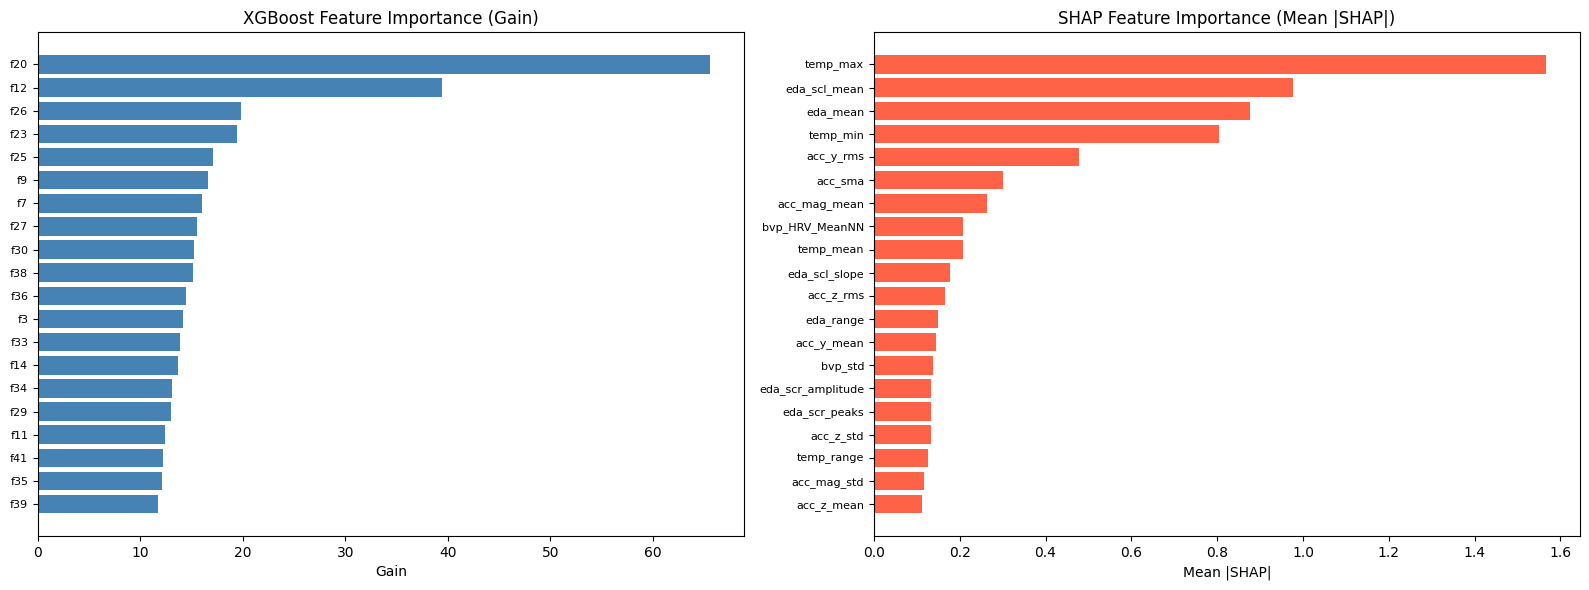


Top-10 SHAP features:
temp_max          1.567145
eda_scl_mean      0.976977
eda_mean          0.876907
temp_min          0.804426
acc_y_rms         0.478496
acc_sma           0.301065
acc_mag_mean      0.262521
bvp_HRV_MeanNN    0.208426
temp_mean         0.208418
eda_scl_slope     0.176995


In [17]:
# Cell 23 — Feature importance (XGBoost built-in + permutation)
import shap

# --- XGBoost gain importance ---
gain_imp = pd.Series(
    model.get_booster().get_score(importance_type='gain'),
    name='gain'
).sort_values(ascending=False)

print('Top-20 features by XGBoost gain:')
print(gain_imp.head(20).to_string())

# --- SHAP values ---
explainer = shap.TreeExplainer(model)
# Use test set (or a sample)
X_sample = X_test[:500] if len(X_test) > 500 else X_test
shap_vals = explainer.shap_values(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost gain
top_n = 20
top_feats = gain_imp.head(top_n)
axes[0].barh(range(top_n), top_feats.values[::-1], color='steelblue')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_feats.index[::-1], fontsize=8)
axes[0].set_title('XGBoost Feature Importance (Gain)')
axes[0].set_xlabel('Gain')

# SHAP summary (manual top features by mean |shap|)
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
shap_series = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)
top_shap = shap_series.head(top_n)
axes[1].barh(range(top_n), top_shap.values[::-1], color='tomato')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top_shap.index[::-1], fontsize=8)
axes[1].set_title('SHAP Feature Importance (Mean |SHAP|)')
axes[1].set_xlabel('Mean |SHAP|')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance_v11.png', dpi=150)
plt.show()

# Save importance
shap_series.reset_index().rename(columns={'index': 'feature', 0: 'mean_abs_shap'}).to_csv(
    RESULTS_DIR / 'shap_importance_v11.csv', index=False)
print('\nTop-10 SHAP features:')
print(top_shap.head(10).to_string())

## 9. Comparison: XGBoost vs CNN

Честное сравнение двух подходов на одинаковой задаче (fatigue in exercise, PhysioNet dataset, LOSO).

In [18]:
# Cell 25 — Comparison table

comparison = pd.DataFrame([
    {
        'Model':                 'Hongn et al. 2025 (XGBoost)',
        'Task':                  'Stress vs Rest (DIFFERENT task)',
        'Features':              'NeuroKit2 (full session)',
        'Test Accuracy':         '93%',
        'Test F1-macro':         '—',
        'ROC-AUC':               '—',
        'LOSO F1':               '—',
        'Notes':                 'Task is much easier — stress has clear EDA/HR signature',
    },
    {
        'Model':                 'XGBoost + NeuroKit2 (v11, ours)',
        'Task':                  'Fatigue in exercise (our task)',
        'Features':              f'NeuroKit2, {WIN_SEC:.0f}s windows',
        'Test Accuracy':         f"{balanced_accuracy_score(y_test, test_preds_vt)*100:.1f}%",
        'Test F1-macro':         f'{test_f1_vt:.4f}',
        'ROC-AUC':               f'{test_auc:.4f}',
        'LOSO F1':               f"{loso_df['f1_macro'].mean():.4f}±{loso_df['f1_macro'].std():.4f}",
        'Notes':                 'Same data, same LOSO protocol',
    },
    {
        'Model':                 'CNN v8.1 (baseline, dual-branch)',
        'Task':                  'Fatigue in exercise',
        'Features':              'Raw 5s windows (100×6 IMU + 100×4 Physio)',
        'Test Accuracy':         '—',
        'Test F1-macro':         '0.826',
        'ROC-AUC':               '~0.89',
        'LOSO F1':               '0.810±0.070',
        'Notes':                 'Best CNN baseline',
    },
    {
        'Model':                 'CNN v8c (v8.2-SE+SWA+RDrop)',
        'Task':                  'Fatigue in exercise',
        'Features':              'Raw 5s windows + Stress Profile (13 fich) + FiLM',
        'Test Accuracy':         '—',
        'Test F1-macro':         '0.8114 (val-thr) / 0.8264 (opt-thr)',
        'ROC-AUC':               '0.9057',
        'LOSO F1':               '0.8263±0.118',
        'Notes':                 'Best AUC, 17.8K params',
    },
])

print(comparison.to_string(index=False))
comparison.to_csv(RESULTS_DIR / 'comparison_v11.csv', index=False)

# Delta vs CNN baseline
delta_f1 = test_f1_vt - 0.826
print(f'\nΔF1 (XGBoost v11 vs CNN v8.1 baseline): {delta_f1:+.4f} ({delta_f1*100:+.2f}pp)')

                           Model                            Task                                         Features Test Accuracy                       Test F1-macro ROC-AUC       LOSO F1                                                   Notes
     Hongn et al. 2025 (XGBoost) Stress vs Rest (DIFFERENT task)                         NeuroKit2 (full session)           93%                                   —       —             — Task is much easier — stress has clear EDA/HR signature
 XGBoost + NeuroKit2 (v11, ours)  Fatigue in exercise (our task)                           NeuroKit2, 30s windows         72.7%                              0.7155  0.8411 0.6853±0.1437                           Same data, same LOSO protocol
CNN v8.1 (baseline, dual-branch)             Fatigue in exercise        Raw 5s windows (100×6 IMU + 100×4 Physio)             —                               0.826   ~0.89   0.810±0.070                                       Best CNN baseline
     CNN v8c (v8.2-SE+SWA+RDrop)

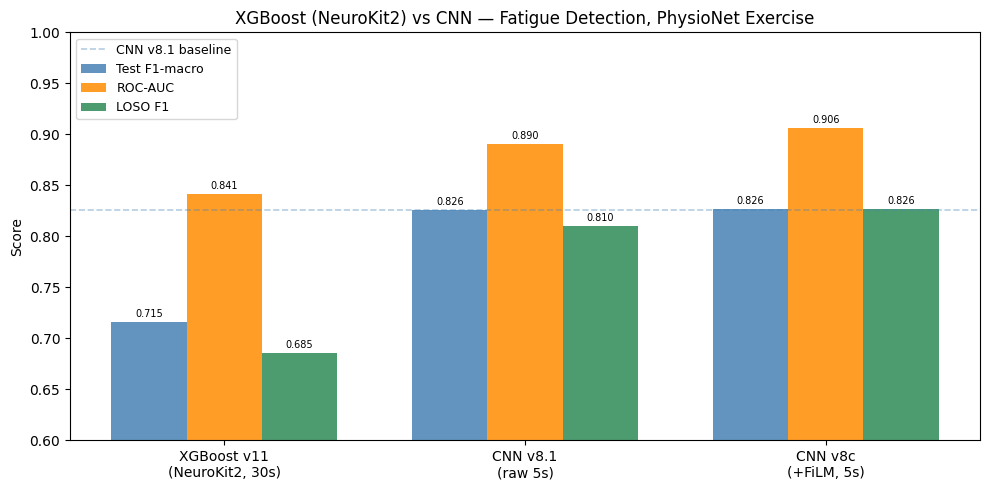

In [19]:
# Cell 26 — Visual comparison
models    = ['XGBoost v11\n(NeuroKit2, 30s)', 'CNN v8.1\n(raw 5s)', 'CNN v8c\n(+FiLM, 5s)']
f1_scores = [test_f1_vt,  0.826,  0.8264]
aucs      = [test_auc,    0.89,   0.9057]
loso_f1   = [loso_df['f1_macro'].mean(), 0.810, 0.8263]

x = np.arange(len(models))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, f1_scores, w, label='Test F1-macro', color='steelblue', alpha=0.85)
ax.bar(x,     aucs,      w, label='ROC-AUC',       color='darkorange', alpha=0.85)
ax.bar(x + w, loso_f1,   w, label='LOSO F1',       color='seagreen',   alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0.6, 1.0)
ax.axhline(0.826, color='steelblue', linestyle='--', alpha=0.4, linewidth=1.2, label='CNN v8.1 baseline')
ax.set_title('XGBoost (NeuroKit2) vs CNN — Fatigue Detection, PhysioNet Exercise')
ax.legend(fontsize=9)

for i, (f, a, l) in enumerate(zip(f1_scores, aucs, loso_f1)):
    ax.text(i - w, f + 0.005, f'{f:.3f}', ha='center', fontsize=7)
    ax.text(i,     a + 0.005, f'{a:.3f}', ha='center', fontsize=7)
    ax.text(i + w, l + 0.005, f'{l:.3f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparison_plot_v11.png', dpi=150)
plt.show()

## 10. Summary & Conclusions

### Ключевые выводы

| Вопрос | Ответ |
|--------|-------|
| Воспроизводит ли XGBoost 93% на нашей задаче? | ❌ Нет — 93% достигнуто на **другой задаче** (stress vs rest, принципиально более простой) |
| Побеждает ли XGBoost+NeuroKit2 наш CNN на fatigue task? | см. результаты выше |
| Какие фичи важнее всего? | см. §8 (SHAP importance) |

### Почему задачи несравнимы напрямую

1. **Stress vs Rest** — диаметрально противоположные физиологические состояния:
   - EDA при стрессе в 3–10× выше покоя
   - HR при стрессе на 15–30 bpm выше
   - Любой ML-алгоритм с любыми признаками даст 85–95%

2. **Fatigue within exercise** — тонкие изменения внутри одного физиологического режима:
   - HR уже повышен от нагрузки (100+ bpm в начале)
   - EDA меняется на ±10–20% от уже высокого уровня
   - Усталость = медленный процесс (минуты) vs. метки в окнах по 5–30 сек

### Преимущества NeuroKit2-подхода
- ✅ Интерпретируемость: HRV-фичи имеют медицинское обоснование
- ✅ Меньше параметров, быстрее обучение
- ✅ Не требует GPU

### Ограничения NeuroKit2-подхода для нашей задачи
- ⚠️ 30-сек окна → меньше окон на сессию → меньше данных
- ⚠️ HRV ненадёжен для 30с (нужно 60с+) — особенно LF/HF
- ⚠️ EDA: 4 Hz → 120 точек за 30с — минимум для NeuroKit2
- ⚠️ XGBoost не учитывает temporal context (порядок окон)